In [ ]:
import pandas as pd
import optuna
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

In [3]:
# Load the dataset
df = pd.read_csv(r'C:\Users\khiew\Downloads\FYP Augmented (Secondly) Dataset.csv')

In [4]:
# Drop diseases with less than 50 instances
disease_counts = df['diseases'].value_counts()
valid_diseases = disease_counts[disease_counts >= 1000].index
df = df[df['diseases'].isin(valid_diseases)]

# Assuming that the target variable is 'diseases' and all other variables are input features
X = df.drop('diseases', axis=1)
y = df['diseases']

# Encode the target variable (diseases) if it's a categorical variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print("Number of remaining classes in training set:", len(np.unique(y_train)))
print("Number of rows left:", len(df))

Number of remaining classes in training set: 37
Number of rows left: 44748


In [5]:
# Apply SMOTE for class balancing in the training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the new class distribution after SMOTE
print("Class distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print("Number of remaining classes in training set:", len(np.unique(y_train_resampled)))
# Print the number of rows in the resampled training set
print("Number of rows in the resampled training set:", len(X_train_resampled))

Class distribution after SMOTE:
22    1005
27    1005
28    1005
34    1005
6     1005
24    1005
35    1005
12    1005
0     1005
19    1005
18    1005
30    1005
13    1005
5     1005
32    1005
23    1005
16    1005
10    1005
21    1005
33    1005
1     1005
29    1005
4     1005
20    1005
7     1005
31    1005
2     1005
36    1005
8     1005
15    1005
26    1005
9     1005
3     1005
17    1005
25    1005
11    1005
14    1005
Name: count, dtype: int64
Number of remaining classes in training set: 37
Number of rows in the resampled training set: 37185


In [6]:
# Optuna optimization function
def objective(trial):
    # Define the hyperparameters to tune
    n_estimators = trial.suggest_int('n_estimators', 50, 150)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Create RandomForestClassifier with hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    # Perform cross-validation (using 5-fold by default)
    score = cross_val_score(model, X_train_resampled, y_train_resampled, cv=5, scoring='accuracy')
    accuracy = score.mean()

    # Log the hyperparameters and accuracy for this trial
    print(f"Trial {trial.number}: n_estimators={n_estimators}, max_depth={max_depth}, "
          f"min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}, "
          f"max_features={max_features}, Accuracy={accuracy:.4f}")

    return accuracy

In [7]:
# Create Optuna study for optimization with persistent storage
study = optuna.create_study(
    direction='maximize',  # Assuming you are maximizing accuracy
    study_name="randomforest_diseases_symptoms_dropextremelymore1000+SMOTE_SecondAugmentation_study", 
    storage=r"sqlite:///C:/Users/khiew/Downloads/randomforest.db", 
    load_if_exists=True  # Load the study if it already exists, to resume from the last trial
)

# Optimize the study with your objective function, you can adjust the n_trials as needed
study.optimize(objective, n_trials=20)
# Print the best trial and hyperparameters
print("\nBest Trial:")
print(study.best_trial)
print("Best Hyperparameters:")
print(study.best_trial.params)

[I 2025-04-22 19:26:31,370] A new study created in RDB with name: randomforest_diseases_symptoms_dropextremelymore1000+SMOTE_SecondAugmentation_study
[I 2025-04-22 19:26:36,015] Trial 0 finished with value: 0.8391555734839317 and parameters: {'n_estimators': 88, 'max_depth': 17, 'min_samples_split': 11, 'min_samples_leaf': 10, 'max_features': 'log2'}. Best is trial 0 with value: 0.8391555734839317.


Trial 0: n_estimators=88, max_depth=17, min_samples_split=11, min_samples_leaf=10, max_features=log2, Accuracy=0.8392


[I 2025-04-22 19:26:44,335] Trial 1 finished with value: 0.8475460535162027 and parameters: {'n_estimators': 125, 'max_depth': 38, 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 1 with value: 0.8475460535162027.


Trial 1: n_estimators=125, max_depth=38, min_samples_split=10, min_samples_leaf=9, max_features=log2, Accuracy=0.8475


[I 2025-04-22 19:26:49,994] Trial 2 finished with value: 0.8454753260723411 and parameters: {'n_estimators': 74, 'max_depth': 47, 'min_samples_split': 15, 'min_samples_leaf': 11, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8475460535162027.


...

Trial 17: n_estimators=149, max_depth=26, min_samples_split=13, min_samples_leaf=7, max_features=log2, Accuracy=0.8460


[I 2025-04-22 19:30:18,801] Trial 18 finished with value: 0.8491058222401506 and parameters: {'n_estimators': 137, 'max_depth': 34, 'min_samples_split': 18, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 10 with value: 0.8492133924969746.


Trial 18: n_estimators=137, max_depth=34, min_samples_split=18, min_samples_leaf=2, max_features=sqrt, Accuracy=0.8491


[I 2025-04-22 19:30:29,693] Trial 19 finished with value: 0.8479494419792927 and parameters: {'n_estimators': 137, 'max_depth': 35, 'min_samples_split': 18, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 10 with value: 0.8492133924969746.


Trial 19: n_estimators=137, max_depth=35, min_samples_split=18, min_samples_leaf=3, max_features=sqrt, Accuracy=0.8479

Best Trial:
FrozenTrial(number=10, state=TrialState.COMPLETE, values=[0.8492133924969746], datetime_start=datetime.datetime(2025, 4, 22, 19, 28, 52, 934084), datetime_complete=datetime.datetime(2025, 4, 22, 19, 29, 2, 727752), params={'n_estimators': 141, 'max_depth': 32, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_features': 'log2'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=150, log=False, low=50, step=1), 'max_depth': IntDistribution(high=50, log=False, low=10, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1), 'min_samples_leaf': IntDistribution(high=20, log=False, low=1, step=1), 'max_features': CategoricalDistribution(choices=('sqrt', 'log2', None))}, trial_id=452, value=None)
Best Hyperparameters:
{'n_estimators': 141, 'max_depth': 32, 'min_samples_split': 

Model has been trained and saved successfully.


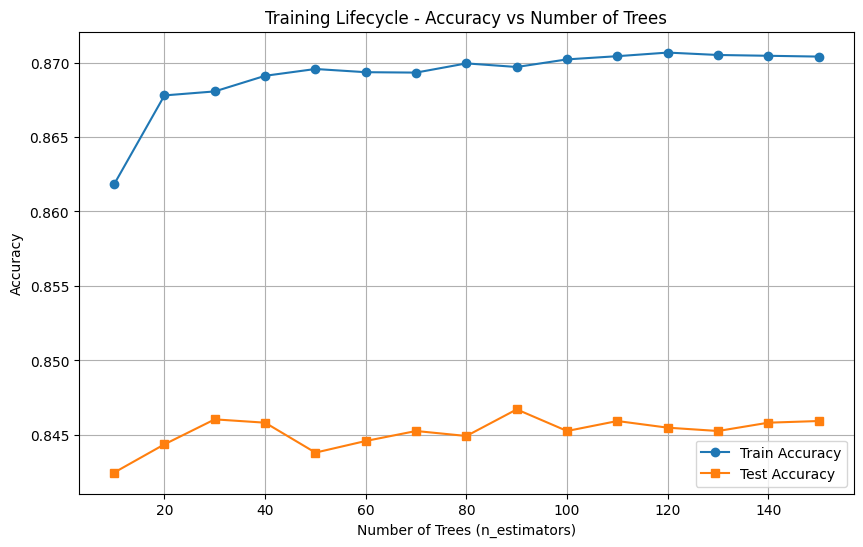

In [7]:
import joblib
import matplotlib.pyplot as plt

# Load existing study from the database
study = optuna.load_study(
    study_name="randomforest_diseases_symptoms_dropextremelymore1000+SMOTE_SecondAugmentation_study",
    storage="sqlite:///C:/Users/khiew/Downloads/randomforest.db"
)

# 1. Create model with best parameters
best_params = study.best_trial.params
best_model = RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    max_features=best_params['max_features'],
    random_state=42
)

# 2. Train model on the resampled training data
best_model.fit(X_train_resampled, y_train_resampled)

# 3. Save the trained model to a file
joblib.dump(best_model, r'C:\Users\khiew\Downloads\first_best_randomforest_model.joblib')

print("Model has been trained and saved successfully.")

# ==========================
# Plotting Training Lifecycle
# ==========================

# Let's simulate a "training curve" by varying number of trees
n_estimators_list = list(range(10, best_params['n_estimators']+10, 10))  # steps of 10 trees
train_accuracies = []
test_accuracies = []

for n in n_estimators_list:
    model = RandomForestClassifier(
        n_estimators=n,
        max_depth=best_params['max_depth'],
        min_samples_split=best_params['min_samples_split'],
        min_samples_leaf=best_params['min_samples_leaf'],
        max_features=best_params['max_features'],
        random_state=42
    )
    model.fit(X_train_resampled, y_train_resampled)

    # Train accuracy
    y_train_pred = model.predict(X_train_resampled)
    train_acc = accuracy_score(y_train_resampled, y_train_pred)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plotting
plt.figure(figsize=(10,6))
plt.plot(n_estimators_list, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(n_estimators_list, test_accuracies, label='Test Accuracy', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Training Lifecycle - Accuracy vs Number of Trees')
plt.legend()
plt.grid(True)
plt.show()
